# Verify Matrix Integrity and Basic stats

## Step 1: Downlad files and verify matrix structures
    - Matrices should all be square 
    - Headers and row indices should match *within* a same matrix
    - Headers (and row indices) should match *between* matrices after removing the segment ID

In [28]:
import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorly as tl
import dask.dataframe as dd
from dask.distributed import Client, SSHCluster
import dask.array as da
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson
import umap


In [29]:
folder = Path("/data/users/ltucker/influenzaData/pipeline/output/1_distances")
files = sorted(folder.glob("*.parquet"))

print(f"Segment {[i for i in range(1,9)]} exist {[os.path.exists(file) for file in files]}")

Segment [1, 2, 3, 4, 5, 6, 7, 8] exist [True, True, True, True, True, True, True, True]


In [30]:
all_segments = []
headers = []
row_indices = []

for index, file in enumerate(files):
    print(f"Index: {index}. file: {file}")

    #open da file 
    df = pd.read_parquet(file)
    df = df.set_index("column00000")
    all_segments.append(df)

    # check squareness 
    print(f"The shape for segment {index+1} is {df.shape}")

    # put all headers in a list
    headers.append(df.columns)
    row_indices.append(df.index)
    

Index: 0. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_1.parquet
The shape for segment 1 is (22334, 22334)
Index: 1. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_2.parquet
The shape for segment 2 is (22334, 22334)
Index: 2. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_3.parquet
The shape for segment 3 is (22334, 22334)
Index: 3. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_4.parquet
The shape for segment 4 is (22334, 22334)
Index: 4. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_5.parquet
The shape for segment 5 is (22334, 22334)
Index: 5. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_6.parquet
The shape for segment 6 is (22334, 22334)
Index: 6. file: /data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_7.parquet
The shape for segment 7 is (22334, 22334)
Index: 7. file: /data/users

In [14]:
# check if headers and row indices match within matrices
for index in range(0, len(headers)):
    print(f"Match between headers and indices in {index+1} : {all(headers[index] == row_indices[index])}")

Match between headers and indices in 1 : True
Match between headers and indices in 2 : True
Match between headers and indices in 3 : True
Match between headers and indices in 4 : True
Match between headers and indices in 5 : True
Match between headers and indices in 6 : True
Match between headers and indices in 7 : True
Match between headers and indices in 8 : True


In [15]:
# get the virus id without the segment info
all_virus_ids = []

for header in headers:
    split_header = [h.split('|') for h in header]
    all_virus_ids.append([parts[1] for parts in split_header]) 

# check if virus ids match between matrices
for index in range(0, len(all_virus_ids)):
    print(f"Virus ids between segment 1 and {index+1} are the same is {all_virus_ids[0] == all_virus_ids[index]}") 

Virus ids between segment 1 and 1 are the same is True
Virus ids between segment 1 and 2 are the same is True
Virus ids between segment 1 and 3 are the same is True
Virus ids between segment 1 and 4 are the same is True
Virus ids between segment 1 and 5 are the same is True
Virus ids between segment 1 and 6 are the same is True
Virus ids between segment 1 and 7 are the same is True
Virus ids between segment 1 and 8 are the same is True


In [25]:
print (headers[0])

Index(['A/H5N0|A/chicken/Fujian/9.24_FZHX0071-O/2018|PB2|1|EPI_ISL_697987|china|asia|2018',
       'A/H5N0|A/chicken/Jiangxi/5.28_NCDZT44N3-OC/2018|PB2|1|EPI_ISL_698015|china|asia|2018',
       'A/H5N0|A/chicken/Yunnan/11.22_DQWGH005-O/2018|PB2|1|EPI_ISL_697983|china|asia|2018',
       'A/H5N0|A/duck/Jiangxi/5.28_NCNP12N3-OC/2018|PB2|1|EPI_ISL_698025|china|asia|2018',
       'A/H5N0|A/duck/Jiangxi/5.28_NCNP34N3-OC/2018|PB2|1|EPI_ISL_698017|china|asia|2018',
       'A/H5N0|A/duck/Zhejiang/11.09_HZBX009-C/2018|PB2|1|EPI_ISL_697941|china|asia|2018',
       'A/H5N0|A/duck/Zhejiang/12.28_HZBX012-O/2018|PB2|1|EPI_ISL_697946|china|asia|2018',
       'A/H5N1|A/?Anser_brachyrhynchus/Belgium/14776_0001/2022|PB2|1|EPI_ISL_16984869|belgium|europe|2022',
       'A/H5N1|A/African_barn_owl/South_Africa/21050429/2021_(H5N1)|PB2|1|EPI_ISL_14644592|south africa|africa|2021',
       'A/H5N1|A/African_black_oystercatcher/South_Africa/682489/2022|PB2|1|EPI_ISL_15853835|south africa|africa|2022',
       ...

## Step 2: get summary statisitcs of each matrix

In [6]:
# Extract upper triangular data from original matrices
triu_indices = np.triu_indices_from(all_segments[0].values, k=0)
all_segments_upper_triangle = [segment.values[triu_indices] for segment in all_segments]

for i, data in enumerate(all_segments_upper_triangle):
    print(f"\n{'='*80}")
    print(f"SEGMENT {i+1}")
    print(f"{'='*80}")
    
    # Basic statistics
    print(f"\nBasic Statistics:")
    print(f"  Count:          {len(data):,}")
    print(f"  Min:            {data.min():.6f}")
    print(f"  Max:            {data.max():.6f}")
    print(f"  Range:          {data.max() - data.min():.6f}")
    print(f"  Mean:           {data.mean():.6f}")
    print(f"  Median:         {np.median(data):.6f}")
    print(f"  Std Dev:        {data.std():.6f}")
    print(f"  Variance:       {data.var():.6f}")
    
    # Percentiles
    print(f"\nPercentiles:")
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        print(f"  {p:2d}th:          {np.percentile(data, p):.6f}")
    
    # IQR
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    print(f"\n  IQR (Q75-Q25):  {iqr:.6f}")
    
    # Distribution shape
    print(f"\nDistribution Shape:")
#    print(f"  Skewness:       {stats.skew(data):.6f}")
#    print(f"  Kurtosis:       {stats.kurtosis(data):.6f}")
    
    # Zero/Non-zero analysis
    n_zeros = np.sum(data == 0)
    n_nonzeros = np.sum(data != 0)
    print(f"\nZero Analysis:")
    print(f"  Zeros:          {n_zeros:,} ({100*n_zeros/len(data):.2f}%)")
    print(f"  Non-zeros:      {n_nonzeros:,} ({100*n_nonzeros/len(data):.2f}%)")
    
    # Outlier analysis (using IQR method)
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    n_outliers_low = np.sum(data < lower_bound)
    n_outliers_high = np.sum(data > upper_bound)
    print(f"\nOutliers (IQR method):")
    print(f"  Lower bound:    {lower_bound:.6f}")
    print(f"  Upper bound:    {upper_bound:.6f}")
    print(f"  Below lower:    {n_outliers_low:,} ({100*n_outliers_low/len(data):.2f}%)")
    print(f"  Above upper:    {n_outliers_high:,} ({100*n_outliers_high/len(data):.2f}%)")
    
    # Non-zero statistics (if applicable)
    if n_nonzeros > 0:
        data_nonzero = data[data != 0]
        print(f"\nNon-Zero Statistics:")
        print(f"  Min (non-zero): {data_nonzero.min():.6f}")
        print(f"  Max (non-zero): {data_nonzero.max():.6f}")
        print(f"  Mean (non-zero):{data_nonzero.mean():.6f}")
        print(f"  Median (n-zero):{np.median(data_nonzero):.6f}")


SEGMENT 1

Basic Statistics:
  Count:          249,414,945
  Min:            0.000000
  Max:            0.749568
  Range:          0.749568
  Mean:           0.057684
  Median:         0.064926
  Std Dev:        0.020390
  Variance:       0.000416

Percentiles:
   1th:          0.003521
   5th:          0.018004
  10th:          0.029467
  25th:          0.045872
  50th:          0.064926
  75th:          0.070294
  90th:          0.073209
  95th:          0.075034
  99th:          0.081455

  IQR (Q75-Q25):  0.024422

Distribution Shape:

Zero Analysis:
  Zeros:          95,742 (0.04%)
  Non-zeros:      249,319,203 (99.96%)

Outliers (IQR method):
  Lower bound:    0.009239
  Upper bound:    0.106927
  Below lower:    5,817,808 (2.33%)
  Above upper:    626,571 (0.25%)

Non-Zero Statistics:
  Min (non-zero): 0.000427
  Max (non-zero): 0.749568
  Mean (non-zero):0.057706
  Median (n-zero):0.064927

SEGMENT 2

Basic Statistics:
  Count:          249,414,945
  Min:            0.000000
 

## Step 3: plot histograms per segment and attempt normalization

In [10]:
# Extract data
triu_indices = np.triu_indices_from(all_segments[0].values, k=0)

# Try different transformations
transformations = {
    'Original': [segment.values[triu_indices] for segment in all_segments],
    'Log1p': [np.log1p(segment.values[triu_indices]) for segment in all_segments],
    'Sqrt': [np.sqrt(segment.values[triu_indices]) for segment in all_segments],
    'Inverse': [1 / (segment.values[triu_indices + 1e16)] for segment in all_segments]
    'Arcsinh': [np.arcsinh(segment.values[triu_indices]) for segment in all_segments],
}

KeyboardInterrupt: 

In [ ]:
# Add Yeo-Johnson
yj_transformed = []
for segment in all_segments:
    data = segment.values[triu_indices]
    transformed, lambda_param = yeojohnson(data)
    yj_transformed.append(transformed)
transformations['Yeo-Johnson'] = yj_transformed

In [ ]:
# Plot comparison for first segment only
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for ax, (name, data_list) in zip(axes, transformations.items()):
    data = data_list[0]  # First segment only
    ax.hist(data, bins=100, edgecolor='k', alpha=0.7)
    ax.set_title(f'{name}\nSkew={np.abs(((data - np.median(data))**3).mean() / data.std()**3):.2f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Print skewness comparison
print("\nSkewness Comparison (Segment 1):")
print("="*50)
for name, data_list in transformations.items():
    from scipy.stats import skew
    skewness = skew(data_list[0])
    print(f"{name:15s}: {skewness:8.3f}")

## Step 4: mode based normalization.
    First, 2 way normalization will be done and plotted for segment 1.

In [16]:
segment_1_row_means = all_segments[0].mean(axis=1)
segment_1_row_medians = all_segments[0].median(axis=1)
print(segment_1_row_medians - segment_1_row_means)

column00000
A/H5N0|A/Duck/China/69361/2020|PB2|1|EPI_ISL_16868591|mexico|americas|2020                       -0.075580
A/H5N0|A/chicken/Fujian/9.24_FZHX0071-O/2018|PB2|1|EPI_ISL_697987|china|asia|2018                -0.073129
A/H5N0|A/chicken/Jiangxi/5.28_NCDZT44N3-OC/2018|PB2|1|EPI_ISL_698015|china|asia|2018             -0.074066
A/H5N0|A/chicken/Xinjiang/10.13_WLMQXL018-O/2018|PB2|1|EPI_ISL_697088|china|asia|2018            -0.074694
A/H5N0|A/chicken/Yunnan/11.22_DQWGH005-O/2018|PB2|1|EPI_ISL_697983|china|asia|2018               -0.073239
                                                                                                    ...   
A_/_H7N9|A/chicken/Tennessee/17-007147-7/2017|PB2|1|EPI_ISL_276771|united states|americas|2017   -0.067955
A_/_H7N9|A/chicken/Tennessee/17-008152-1/2017|PB2|1|EPI_ISL_276774|united states|americas|2017   -0.067917
A_/_H7N9|A/chicken/Tennessee/17-008279-2/2017|PB2|1|EPI_ISL_276775|united states|americas|2017   -0.067851
A_/_H7N9|A/chicken/Tennes

## Step 5: data subsetting 

In [31]:
np.random.seed()

n_samples = int(0.1 * len(all_segments[0].index))
sample_positions = np.random.choice(len(all_segments[0].index), size=n_samples, replace=False)

subsampled_segments = [segment.iloc[sample_positions, sample_positions] for segment in all_segments]

In [ ]:
/data/users/ltucker/influenzaData/pipeline/output/jupyter_outputs

In [24]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Define percentages to test
percentages = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]  # 5% to 100%

results = []

for pct in percentages:
    n_samples = int(pct * len(all_segments[0]))
    
    # Sample the data
    sample_pos = np.random.choice(len(all_segments[0]), size=n_samples, replace=False)
    subsampled = [seg.iloc[sample_pos, sample_pos] for seg in all_segments]
    
    # Run your clustering (example with your method)
    # labels = your_clustering_function(subsampled)
    
    # Calculate quality metric
    # Option 1: Silhouette score (higher is better, range -1 to 1)
    score = silhouette_score(subsampled[0], labels, metric='precomputed')
    
    # Option 2: Davies-Bouldin score (lower is better)
    # score = davies_bouldin_score(subsampled[0], labels)
    
    results.append({
        'percentage': pct * 100,
        'n_samples': n_samples,
        'score': score
    })

# Convert to DataFrame and plot
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(df_results['percentage'], df_results['score'], marker='o', linewidth=2)
plt.xlabel('Percentage of Data (%)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Clustering Quality vs Data Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(df_results)

NameError: name 'labels' is not defined

## Step 6.1: T-SNE per segment
    - perplexity of 200 and learning rate of 100 was proposed by 

In [19]:
from sklearn.manifold import TSNE

In [20]:
# Compute embeddings and parse metadata for each segment
segments_data = []
#segments_to_process = {4: "HA", 6: "NA"}  # just to process HA NA

for index, df in enumerate(subsampled_segments):
#for index, name in segments_to_process.items(): # just to process HA NA
    print(f"Processing segment {index + 1}...")
    
    # Compute t-SNE embedding once
    print(f"  Computing t-SNE...")
    tsne = TSNE( n_components=2, 
                random_state=42, 
                perplexity=200,
                learning_rate=100,
                metric="precomputed",
                init="random",
                max_iter=5000,      
                n_iter_without_progress=100  # 400 takes too long Shit bout to take forever
               )
    embedding = tsne.fit_transform(df.values)
    
    # Parse metadata from index
    metadata = pd.DataFrame({"sample_id": df.index})
    
    # Header format: A_/_H7N9|A/chicken/Tennessee/17-007147-7/2017|PB2|1|EPI_ISL_276771|united states|americas|2017
    # Positions:     0      |1                                    |2  |3|4            |5            |6       |7
    metadata["country"] = metadata["sample_id"].str.split("|").str[5]
    metadata["continent"] = metadata["sample_id"].str.split("|").str[6]
    metadata["year"] = metadata["sample_id"].str.split("|").str[7]
    
    # Add embedding coordinates
    metadata["tsne_1"] = embedding[:, 0]
    metadata["tsne_2"] = embedding[:, 1]
    
    segments_data.append({
        "segment": index + 1,
        "embedding": embedding,
        "metadata": metadata
    })
    
    print(f"  Unique countries: {metadata['country'].nunique()}, years: {metadata['year'].nunique()}")

Processing segment 1...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 2...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 3...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 4...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 5...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 6...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 7...
  Computing t-SNE...
  Unique countries: 79, years: 36
Processing segment 8...
  Computing t-SNE...
  Unique countries: 79, years: 36


In [21]:
def plot_tsne_by_metadata(segments_data, color_by):
    """Plot t-SNE for all segments, colored by a metadata column."""
    fig, axes = plt.subplots(8, 1, figsize=(8, 16))
    axes = axes.flatten()
    
    # Get all unique categories across all segments for consistent colors
    all_categories = set()
    for data in segments_data:
        all_categories.update(data["metadata"][color_by].unique())
    all_categories = sorted(all_categories)
    
    palette = plt.cm.tab20(np.linspace(0, 1, len(all_categories)))
    color_map = dict(zip(all_categories, palette))
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        colors = [color_map[val] for val in meta[color_by]]
        
        ax.scatter(meta["tsne_1"], meta["tsne_2"], c=colors, s=5, alpha=0.6)
        ax.set_title(f"Segment {data['segment']}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
    
    # Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color_map[cat], markersize=8, label=cat) 
               for cat in all_categories]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.suptitle(f"t-SNE colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_tsne_continuous(segments_data, color_by, cmap="viridis"):
    """Plot t-SNE colored by a continuous/numeric metadata column."""
    fig, axes = plt.subplots(8, 1, figsize=(32, 8))
    axes = axes.flatten()
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        values = pd.to_numeric(meta[color_by], errors="coerce")
        
        scatter = ax.scatter(
            meta["tsne_1"], meta["tsne_2"], 
            c=values, s=5, alpha=0.6, cmap=cmap,
            vmin=2000, vmax=2025
        )
        ax.set_title(f"Segment {data['segment']}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
    
    plt.colorbar(scatter, ax=axes, label=color_by, shrink=0.6)
    plt.suptitle(f"t-SNE colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()

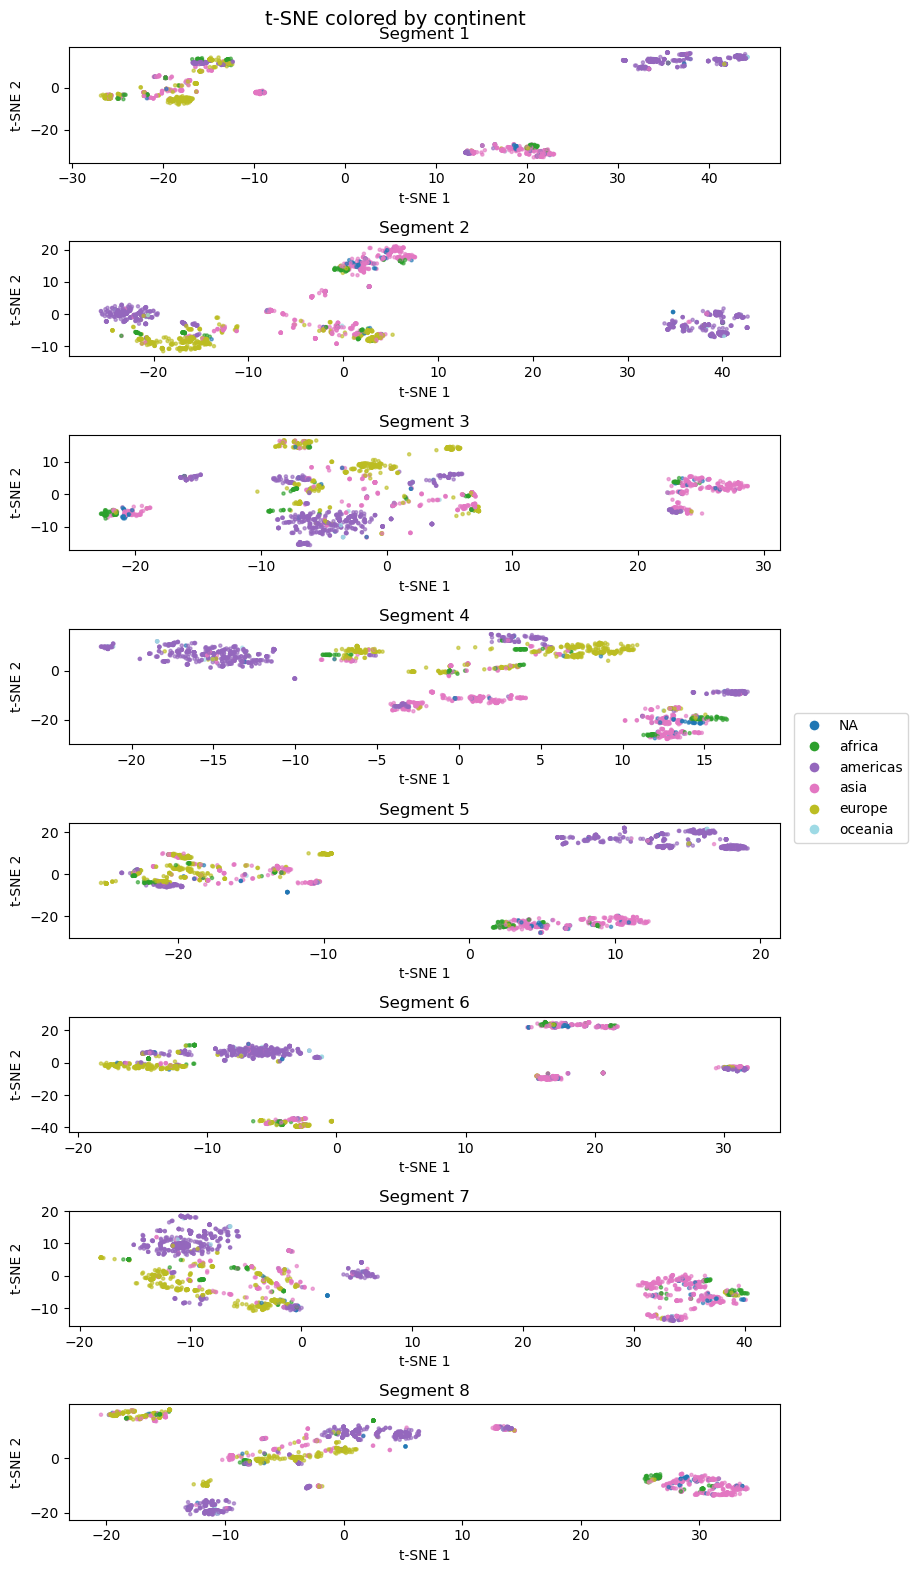

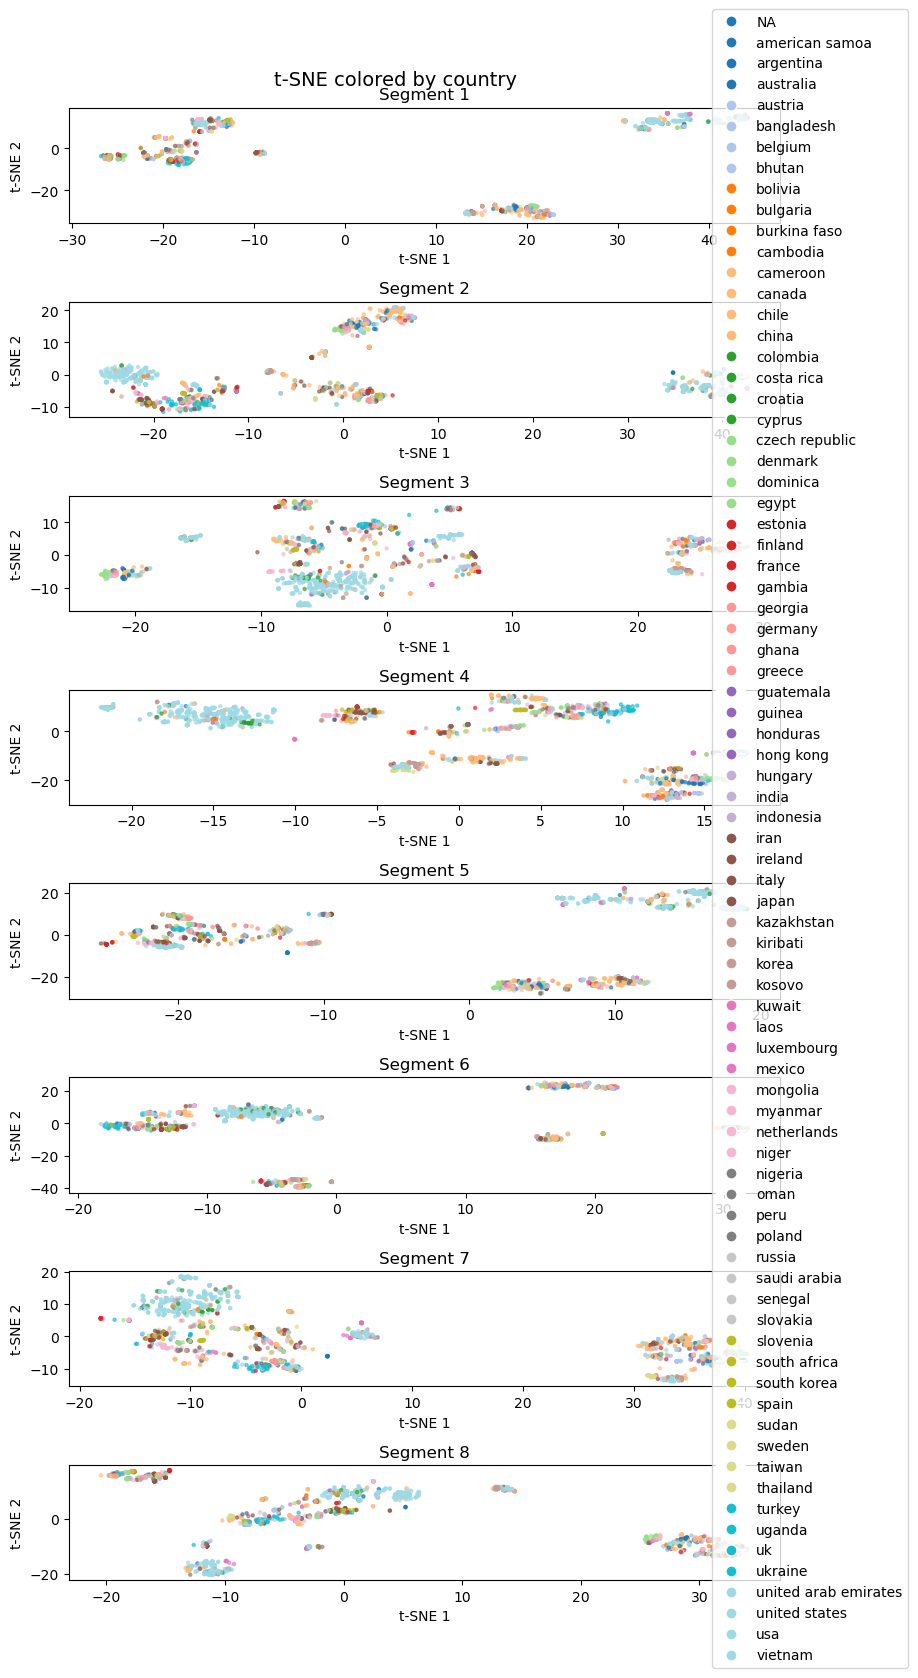

/tmp/ipykernel_2173888/4225529710.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


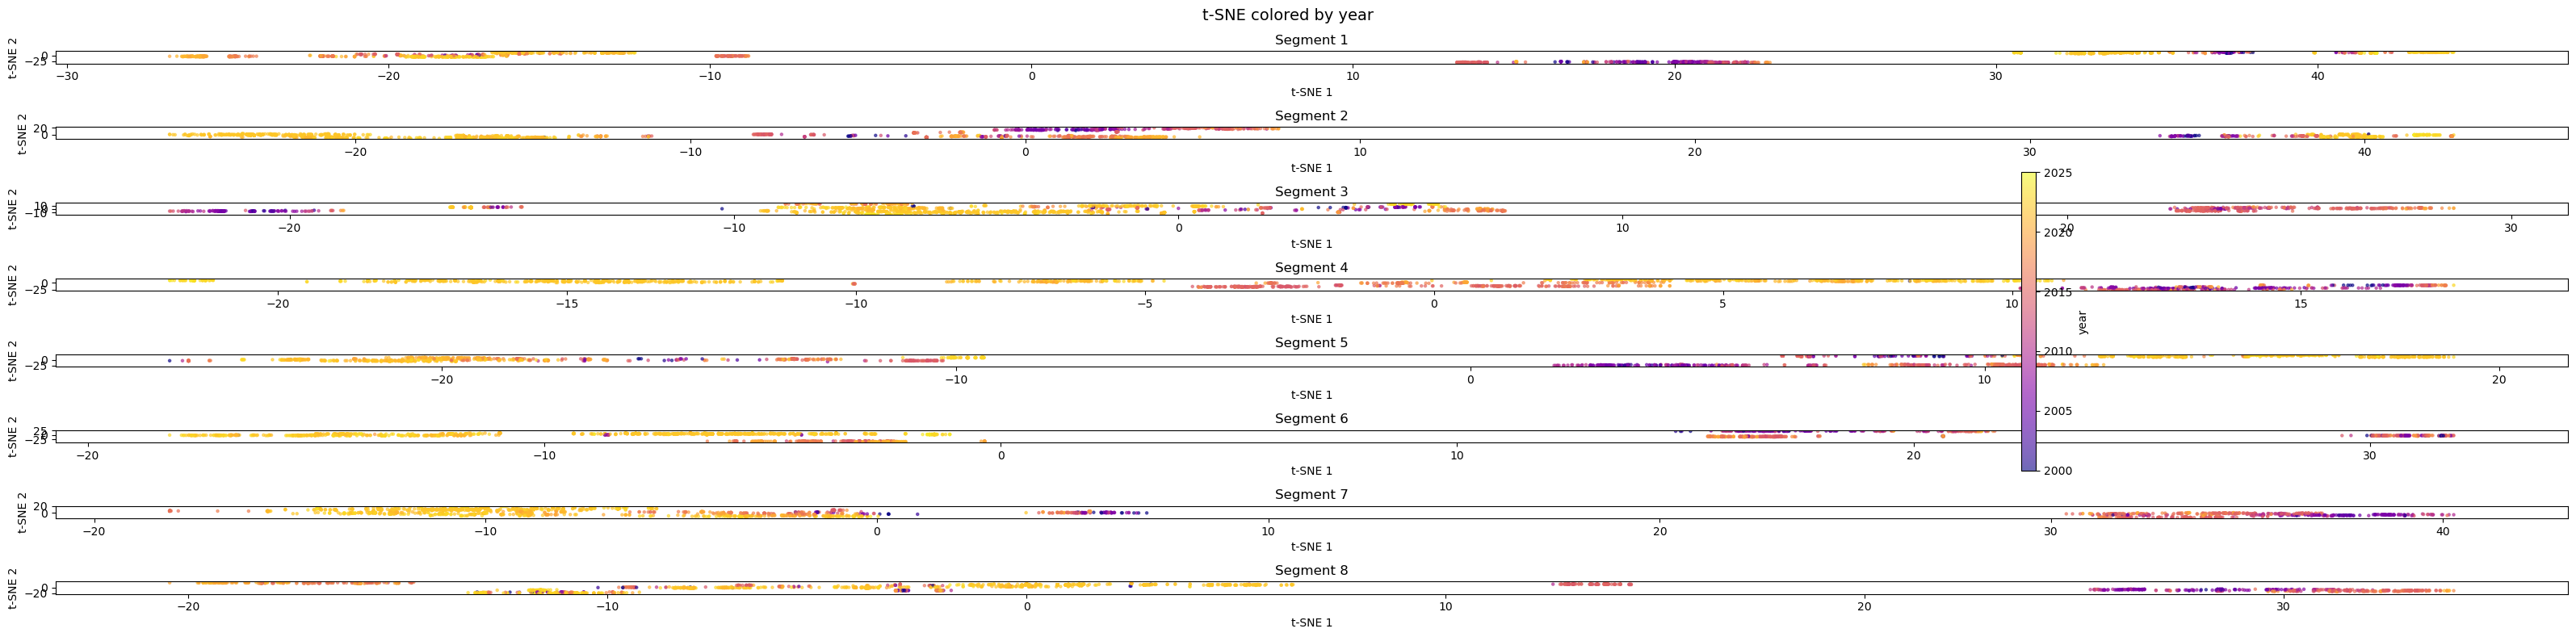

In [22]:
# Categorical plots
plot_tsne_by_metadata(segments_data, color_by="continent")
plot_tsne_by_metadata(segments_data, color_by="country")

# Continuous plot for year
plot_tsne_continuous(segments_data, color_by="year", cmap="plasma")

## Sep 5.2: UMAP per segment

In [32]:
# Compute UMAP embeddings
segments_data_umap = []
#segments_to_process = {4: "HA", 6: "NA"}  # just to process HA NA

for index, df in enumerate(subsampled_segments):
#for index, name in segments_to_process.items(): # just to process HA NA
    print(f"Processing segment {index + 1}...")
    print(f"  Computing UMAP...")
    
    reducer = umap.UMAP(
        n_components=2,
        random_state=42,
        metric="precomputed",
        n_neighbors=100,
        min_dist=0.1
    )
    embedding = reducer.fit_transform(df.values)
    
    # Parse metadata
    metadata = pd.DataFrame({"sample_id": df.index})
    metadata["country"] = metadata["sample_id"].str.split("|").str[5]
    metadata["continent"] = metadata["sample_id"].str.split("|").str[6]
    metadata["year"] = metadata["sample_id"].str.split("|").str[7]
    
    metadata["umap_1"] = embedding[:, 0]
    metadata["umap_2"] = embedding[:, 1]
    
    segments_data_umap.append({
        "segment": index + 1,
        "embedding": embedding,
        "metadata": metadata
    })
    
    print(f"  Unique countries: {metadata['country'].nunique()}, years: {metadata['year'].nunique()}")


Processing segment 1...
  Computing UMAP...


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Unique countries: 73, years: 31
Processing segment 2...
  Computing UMAP...


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Unique countries: 73, years: 31
Processing segment 3...
  Computing UMAP...


...

  Unique countries: 73, years: 31
Processing segment 7...
  Computing UMAP...


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Unique countries: 73, years: 31
Processing segment 8...
  Computing UMAP...


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Unique countries: 73, years: 31


In [33]:
def plot_umap_by_metadata(segments_data, color_by):
    """Plot UMAP for all segments, colored by a metadata column."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    all_categories = set()
    for data in segments_data:
        all_categories.update(data["metadata"][color_by].unique())
    all_categories = sorted(all_categories)
    
    palette = plt.cm.tab20(np.linspace(0, 1, len(all_categories)))
    color_map = dict(zip(all_categories, palette))
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        colors = [color_map[val] for val in meta[color_by]]
        
        ax.scatter(meta["umap_1"], meta["umap_2"], c=colors, s=5, alpha=0.6)
        ax.set_title(f"Segment {data['segment']}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
    
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color_map[cat], markersize=8, label=cat) 
               for cat in all_categories]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.suptitle(f"UMAP colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_umap_continuous(segments_data, color_by, cmap="viridis"):
    """Plot UMAP colored by a continuous/numeric metadata column."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        values = pd.to_numeric(meta[color_by], errors="coerce")
        
        scatter = ax.scatter(
            meta["umap_1"], meta["umap_2"], 
            c=values, s=5, alpha=0.6, cmap=cmap,
            vmin=2000, vmax=2025
        )
        ax.set_title(f"Segment {data['segment']}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
    
    plt.colorbar(scatter, ax=axes, label=color_by, shrink=0.6)
    plt.suptitle(f"UMAP colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()


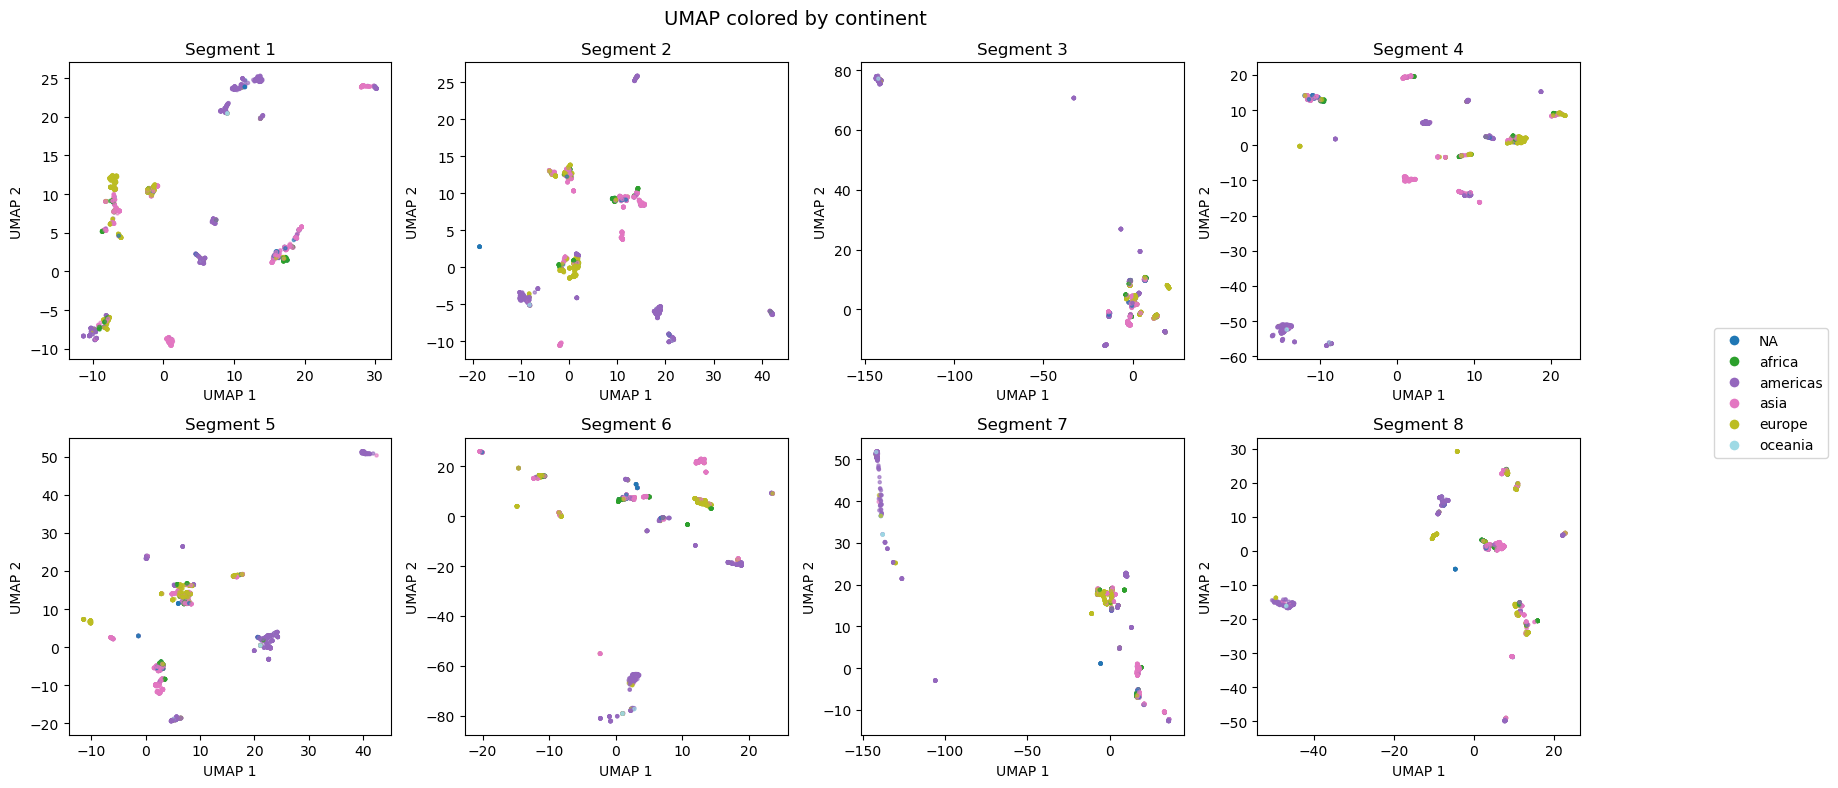

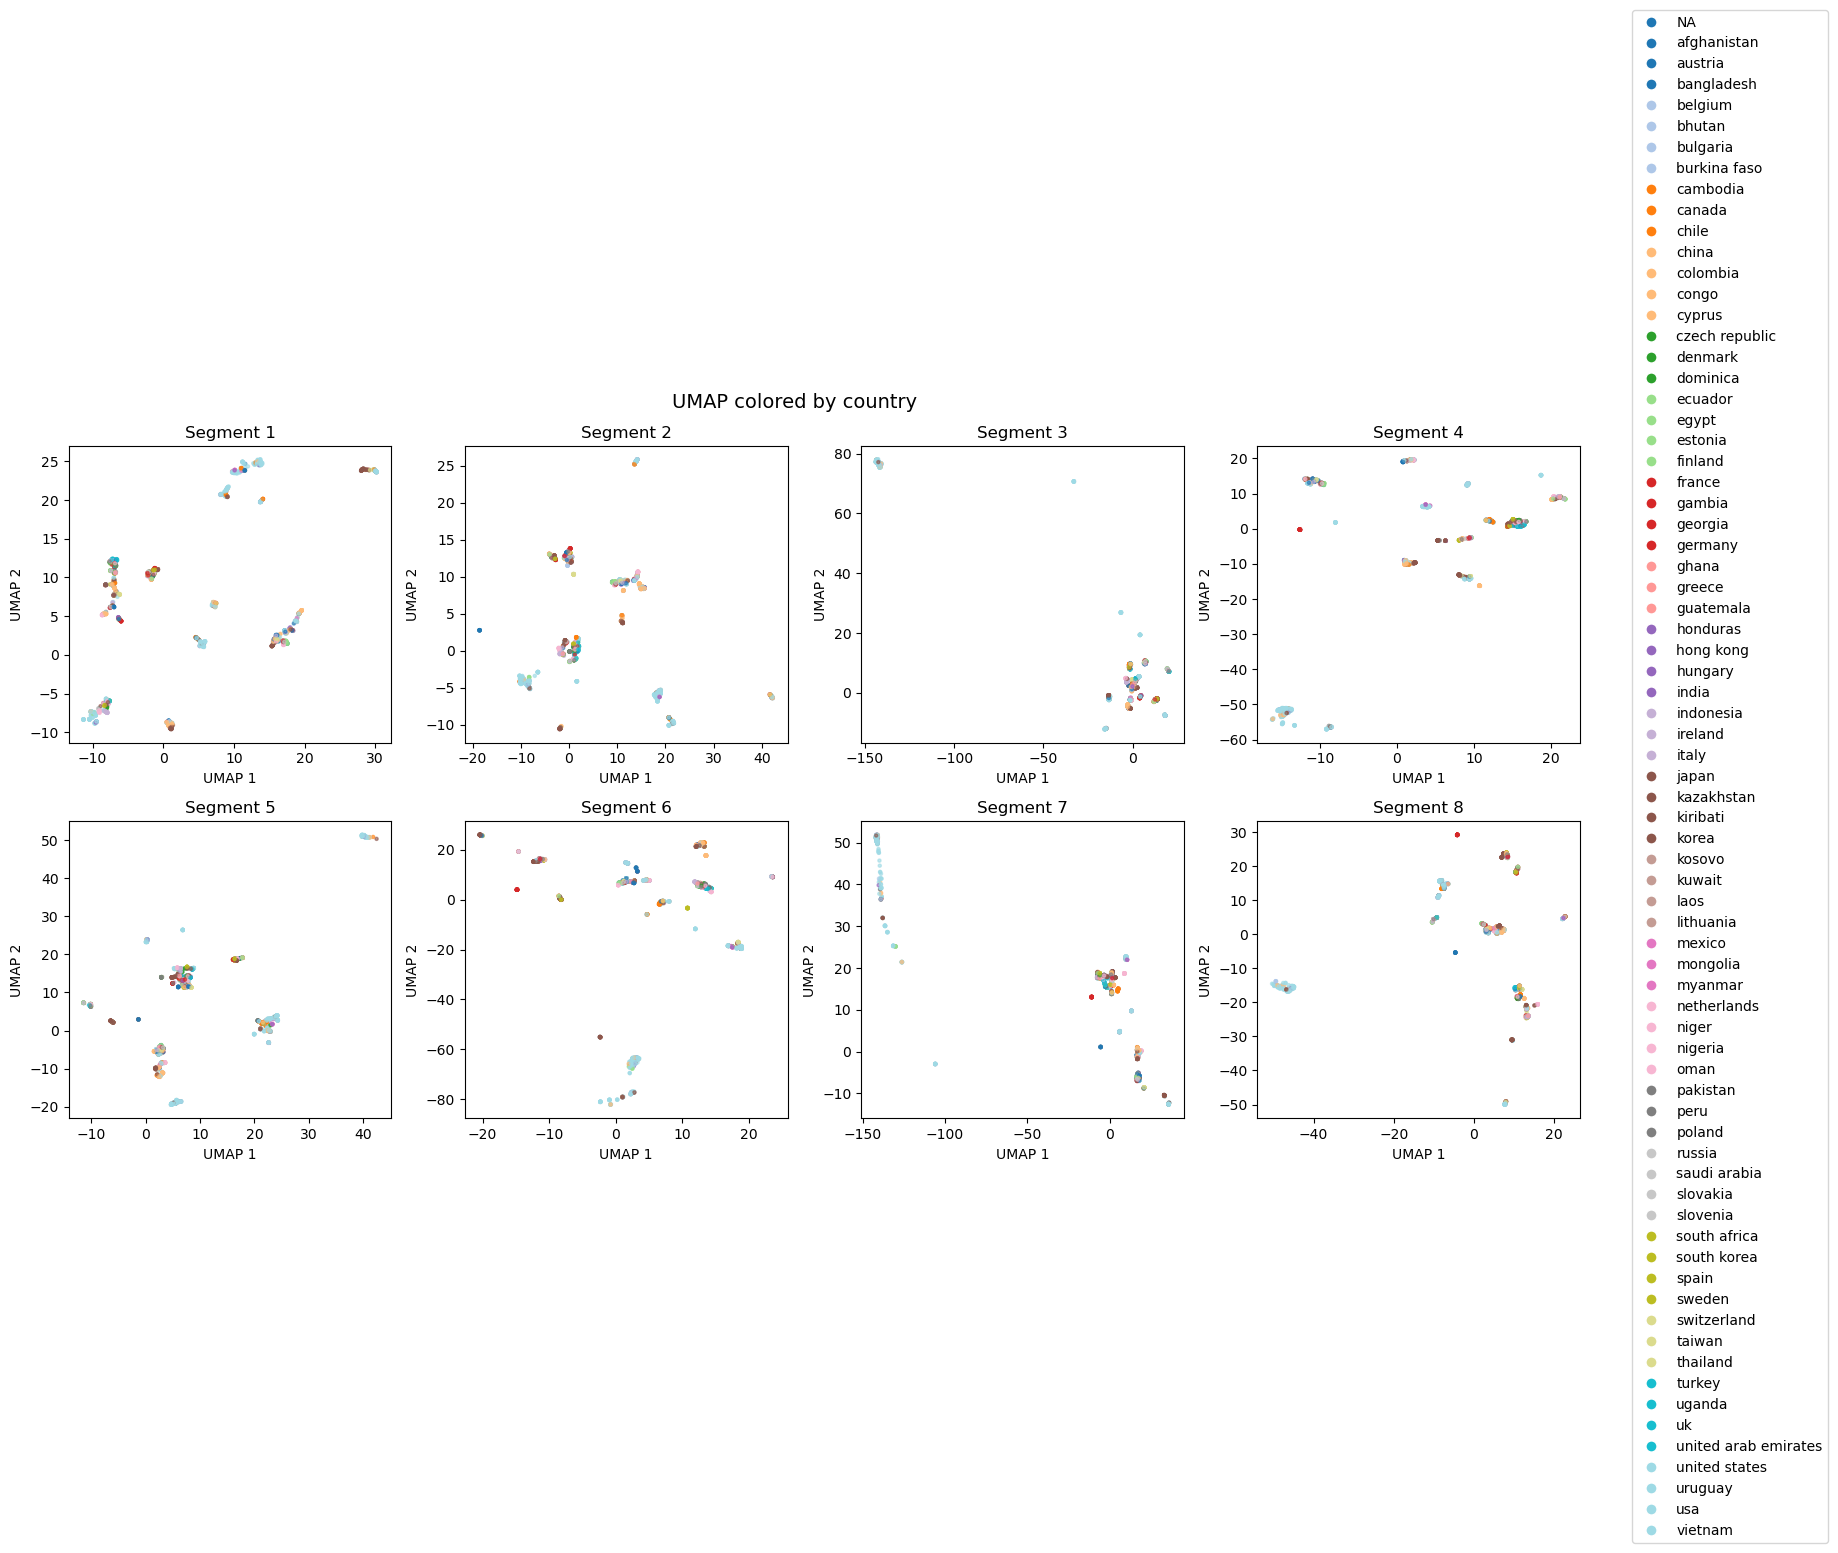

/tmp/ipykernel_2173888/620584520.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


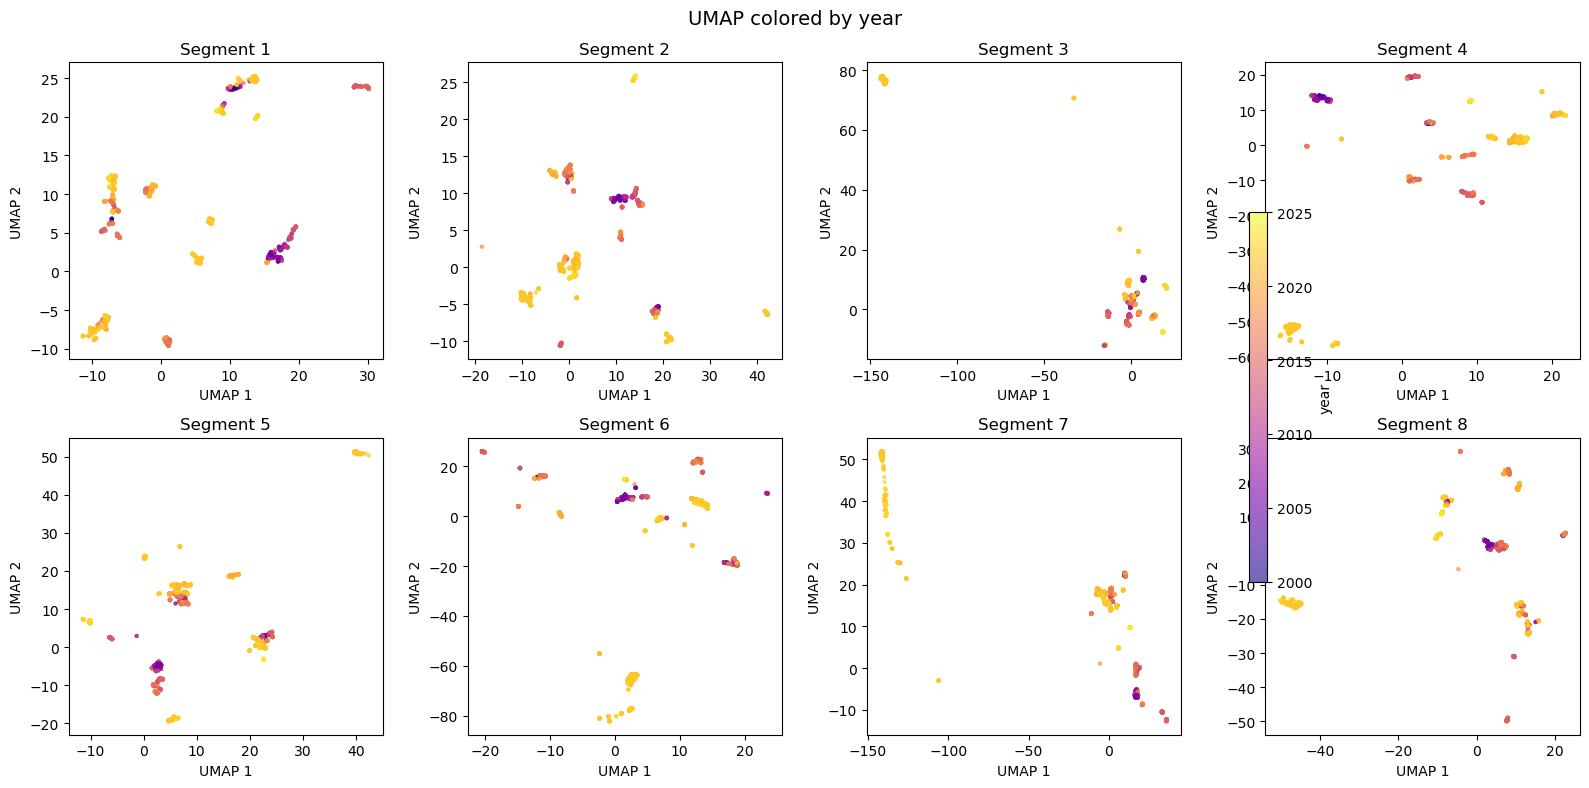

In [34]:
# Plot UMAP results
plot_umap_by_metadata(segments_data_umap, color_by="continent")
plot_umap_by_metadata(segments_data_umap, color_by="country")
plot_umap_continuous(segments_data_umap, color_by="year", cmap="plasma")

## Step 5.2: MDS per segment

In [ ]:
from sklearn.manifold import MDS

In [ ]:
# Compute MDS embeddings
segments_data = []
segments_to_process = {4: "HA", 6: "NA"}  # just to process HA NA

for index, df in enumerate(subsampled_segments):
# for index, name in segments_to_process.items(): # just to process HA NA
    print(f"Processing segment {index + 1}...")
    print(f"  Computing MDS...")

    #Force symmetry by averaging with transpose
    distance_matrix = df.values
    distance_matrix = (distance_matrix + distance_matrix.T) / 2

    mds = MDS(
        n_components=2,
        random_state=42,
        dissimilarity="precomputed",  # Note: MDS uses "dissimilarity" not "metric"
        normalized_stress="auto",
        max_iter=100
    )
    embedding = mds.fit_transform(distance_matrix)
    
    # Parse metadata
    metadata = pd.DataFrame({"sample_id": df.index})
    metadata["country"] = metadata["sample_id"].str.split("|").str[5]
    metadata["continent"] = metadata["sample_id"].str.split("|").str[6]
    metadata["year"] = metadata["sample_id"].str.split("|").str[7]
    
    metadata["mds_1"] = embedding[:, 0]
    metadata["mds_2"] = embedding[:, 1]
    
    segments_data_mds.append({
        "segment": index + 1,
        "embedding": embedding,
        "metadata": metadata,
        "stress": mds.stress_  # MDS provides a stress value (lower = better fit)
    })
    
    print(f"  Stress: {mds.stress_:.4f}")
    print(f"  Unique countries: {metadata['country'].nunique()}, years: {metadata['year'].nunique()}")


In [ ]:
def plot_mds_by_metadata(segments_data, color_by):
    """Plot MDS for all segments, colored by a metadata column."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    all_categories = set()
    for data in segments_data:
        all_categories.update(data["metadata"][color_by].unique())
    all_categories = sorted(all_categories)
    
    palette = plt.cm.tab20(np.linspace(0, 1, len(all_categories)))
    color_map = dict(zip(all_categories, palette))
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        colors = [color_map[val] for val in meta[color_by]]
        
        ax.scatter(meta["mds_1"], meta["mds_2"], c=colors, s=5, alpha=0.6)
        ax.set_title(f"Segment {data['segment']} (stress: {data['stress']:.2f})")
        ax.set_xlabel("MDS 1")
        ax.set_ylabel("MDS 2")
    
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color_map[cat], markersize=8, label=cat) 
               for cat in all_categories]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.suptitle(f"MDS colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()



def plot_mds_continuous(segments_data, color_by, cmap="viridis"):
    """Plot MDS colored by a continuous/numeric metadata column."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, data in enumerate(segments_data):
        ax = axes[i]
        meta = data["metadata"]
        values = pd.to_numeric(meta[color_by], errors="coerce")
        
        scatter = ax.scatter(
            meta["mds_1"], meta["mds_2"], 
            c=values, s=5, alpha=0.6, cmap=cmap,
            vmin=2000, vmax=2025
        )
        ax.set_title(f"Segment {data['segment']} (stress: {data['stress']:.2f})")
        ax.set_xlabel("MDS 1")
        ax.set_ylabel("MDS 2")
    
    plt.colorbar(scatter, ax=axes, label=color_by, shrink=0.6)
    plt.suptitle(f"MDS colored by {color_by}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
# Plot MDS results
plot_mds_by_metadata(segments_data_mds, color_by="continent")
plot_mds_by_metadata(segments_data_mds, color_by="country")
plot_mds_continuous(segments_data_mds, color_by="year", cmap="plasma")